In [1]:
import os
import numpy as np
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors
import warnings
import seaborn as sns
from scipy import stats
import matplotlib.patches as mpatches
from intervaltree import IntervalTree
from sortedcontainers import SortedList

In [3]:
import pandas as pd
from scipy.stats import mannwhitneyu

def mann_whitney_test(df, label_col, value_col):
    """
    Perform the Mann-Whitney U test on the specified columns of the DataFrame.
    
    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    label_col (str): The name of the column to be used as the label.
    value_col (str): The name of the column to be used as the values.
    
    Returns:
    result (dict): A dictionary containing the U statistic and p-value of the test.
    """
    # Ensure the columns exist in the DataFrame
    if label_col not in df.columns or value_col not in df.columns:
        raise ValueError(f"Columns '{label_col}' and/or '{value_col}' not found in DataFrame")
    
    # Extract the groups based on the label column
    groups = df.groupby(label_col)[value_col].apply(list)
    
    # Ensure there are exactly two groups for the Mann-Whitney U test
    if len(groups) != 2:
        raise ValueError("The label column must have exactly two unique values for the Mann-Whitney U test")
    
    group1, group2 = groups.iloc[0], groups.iloc[1]
    
    # Perform the Mann-Whitney U test
    u_statistic, p_value = mannwhitneyu(group1, group2)
    
    # Return the result as a dictionary
    return p_value, u_statistic


def find_regions_within_reference(ref_df, query_df, query_id_col, 
                                  ref_chrom_col='genoName', ref_start_col='genoStart', ref_end_col='genoEnd', query_chrom_col='genoName',
                                  query_start_col='genoStart', query_end_col='genoEnd'):
    # Build interval trees for each chromosome in the reference
    interval_trees = {}
    for idx, row in ref_df.iterrows():
        chrom = row[ref_chrom_col]
        if chrom not in interval_trees:
            interval_trees[chrom] = IntervalTree()
        interval_trees[chrom].addi(row[ref_start_col], row[ref_end_col], idx)

    # Find query regions within reference regions
    ref_df['query_ids'] = ""
    for idx, row in query_df.iterrows():
        chrom = row[query_chrom_col]
        if chrom in interval_trees:
            overlapping_intervals = interval_trees[chrom][row[query_start_col]:row[query_end_col]]
            for interval in overlapping_intervals:
                ref_idx = interval.data
                if ref_df.at[ref_idx, 'query_ids']:
                    ref_df.at[ref_idx, 'query_ids'] += f",{row[query_id_col]}"
                else:
                    ref_df.at[ref_idx, 'query_ids'] = row[query_id_col]

    return ref_df

def find_reference_within_query(ref_df, query_df, query_annotation_col, ref_chrom_col='genoName', ref_start_col='genoStart', ref_end_col='genoEnd', query_chrom_col='genoName', query_start_col='genoStart', query_end_col='genoEnd'):
    # Build interval trees for each chromosome in the query
    interval_trees = {}
    for idx, row in query_df.iterrows():
        chrom = row[query_chrom_col]
        if (row[query_start_col] != row[query_end_col]):
            if chrom not in interval_trees:
                interval_trees[chrom] = IntervalTree()
            interval_trees[chrom].addi(row[query_start_col], row[query_end_col], idx)

    # Find reference regions within query regions
    ref_df['query_annotations'] = ""
    for idx, row in ref_df.iterrows():
        chrom = row[ref_chrom_col]
        if chrom in interval_trees:
            overlapping_intervals = interval_trees[chrom][row[ref_start_col]:row[ref_end_col]]
            for interval in overlapping_intervals:
                query_idx = interval.data
                if ref_df.at[idx, 'query_annotations']:
                    ref_df.at[idx, 'query_annotations'] += f",{query_df.at[query_idx, query_annotation_col]}"
                else:
                    ref_df.at[idx, 'query_annotations'] = query_df.at[query_idx, query_annotation_col]

    return ref_df


def build_interval_trees(query_df,  query_chrom_col='genoName', query_start_col='genoStart', query_end_col='genoEnd', query_id_col='id'):
    interval_trees = {}
    sorted_start_positions = {}

    for chrom in query_df[query_chrom_col].unique():
        chrom_df = query_df[query_df[query_chrom_col] == chrom]
        interval_trees[chrom] = SortedList(zip(chrom_df[query_start_col], chrom_df[query_end_col], chrom_df[query_id_col]))
        sorted_start_positions[chrom] = SortedList(chrom_df[query_start_col])

    return interval_trees, sorted_start_positions

def find_closest_region(ref_df, query_df, ref_chrom_col='genoName', ref_start_col='genoStart', ref_end_col='genoEnd', query_chrom_col='genoName', query_start_col='genoStart', query_end_col='genoEnd', query_id_col='id'):
    # Initialize columns in the reference dataframe
    ref_df['closest_query_id'] = ""
    ref_df['distance_to_closest'] = np.inf

    # Build interval trees and sorted start positions for query dataframe
    interval_trees, sorted_start_positions = build_interval_trees(query_df, query_chrom_col, query_start_col, query_end_col, query_id_col)
    
    for ref_idx, ref_row in ref_df.iterrows():
        ref_chrom = ref_row[ref_chrom_col]
        ref_start = ref_row[ref_start_col]
        ref_end = ref_row[ref_end_col]

        if ref_chrom not in interval_trees:
            continue
        
        sorted_starts = sorted_start_positions[ref_chrom]

        # Use bisect to find the closest positions
        pos = sorted_starts.bisect_left(ref_start)
        candidates = []
        if pos < len(sorted_starts):
            candidates.append(pos)
        if pos > 0:
            candidates.append(pos - 1)

        min_distance = np.inf
        closest_query_id = ""

        for candidate in candidates:
            query_start = sorted_starts[candidate]
            for query_start, query_end, query_id in interval_trees[ref_chrom].irange((query_start, ), (query_start, )):
                distance = min(abs(ref_start - query_end), abs(ref_end - query_start))
                if distance < min_distance:
                    min_distance = distance
                    closest_query_id = query_id

        ref_df.at[ref_idx, 'closest_query_id'] = closest_query_id
        ref_df.at[ref_idx, 'distance_to_closest'] = min_distance
    
    return ref_df

In [54]:
# Finding regions from query within reference
# ref_df_with_query_ids = find_regions_within_reference(ref, g, query_id_col='gene_name')
# print(ref_df_with_query_ids)
# Finding regions from reference within query
ref_df_with_query_annotations = find_reference_within_query(g, gtf, query_annotation_col='gene_name')
# print(ref_df_with_query_annotations)

In [4]:
df = pd.read_csv('/home/icb/mostafa.shahhosseini/data/lupien/V2_files/hg38_repeatmasker_table', sep='\t')

In [13]:
# Function to split the string into original parts
def split_string(s):
    # Find the positions of the first two underscores
    matches = [m.start() for m in re.finditer('_', s)]
    if len(matches) < 2:
        return None  # Not enough underscores to split into 3 parts
    
    # Split the string based on the positions of the first two underscores
    part1 = s[:matches[0]]
    part2 = s[matches[0] + 1:matches[1]]
    part3 = s[matches[1] + 1:]
    
    return part1, part2, part3

In [ ]:
df['repName'] = df['repName'].replace('?', '')

df['repClass'] = df['repClass'].replace('?', '')

df['repFamily'] = df['repFamily'].replace('?', '')

p = '/home/icb/mostafa.shahhosseini/data/lupien/V2_files/elements.in.cotes/'
f = os.listdir(p)

g = df.set_index(['repName', 'genoName','genoStart','genoEnd'])
g['CoTE_Present'] = False
g.sort_index(inplace=True)
for i in tqdm(f):
    l = i.split('.')[0]
    c = pd.read_csv(f"/home/icb/mostafa.shahhosseini/data/lupien/V2_files/elements.in.cotes/{l}.elements.cotes.bed", sep='\t', names=['genoName','genoStart','genoEnd'])
    for _, r in c.iterrows():
        g.loc[(split_string(l)[-1], r['genoName'], r['genoStart']), 'CoTE_Present'] = True

g=g.reset_index()

g['length'] = g['genoEnd'] - g['genoStart']

# g.reset_index().to_csv('~/data/lupien/V2_files/repeat_cote_v1.csv')

In [4]:
g = pd.read_csv('~/data/lupien/V2_files/repeat_cote_v1.csv')

In [6]:
g['length'] = g['genoEnd'] - g['genoStart']


## length

/tmp/ipykernel_2811550/731408355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=g['length'], y=g['CoTE_Present'],orient='h', palette=[color1, color2], linecolor='grey', fliersize=.1)


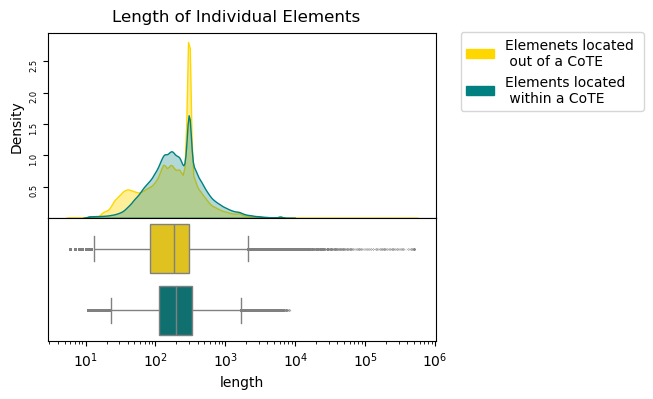

In [56]:
color1 = 'gold'
color2 = 'teal'
fig, axs = plt.subplots(2, 1, figsize=(5, 4), sharex=True, height_ratios=[3, 2])
sns.kdeplot(g[~g['CoTE_Present']].loc[:,'length'].values, fill=True, alpha=0.4, color=color1, ax=axs[0], log_scale=True)
sns.kdeplot(g[g['CoTE_Present']].loc[:,'length'].values, fill=True, alpha=0.3, color=color2, ax=axs[0], log_scale=True)
plt.subplots_adjust(hspace=0)
sns.boxplot(x=g['length'], y=g['CoTE_Present'],orient='h', palette=[color1, color2], linecolor='grey', fliersize=.1)
axs[0].set_yticks([0.5, 1, 1.5, 2, 2.5])
axs[1].set_yticklabels([])
orange_patch = mpatches.Patch(color=color1, label='Elemenets located \n out of a CoTE')
blue_patch = mpatches.Patch(color=color2, label='Elements located \n within a CoTE')
fig.legend(handles=[orange_patch, blue_patch], loc='upper right', bbox_to_anchor=(1.33,.9))
axs[0].tick_params(axis='y', labelsize=6, rotation=90)
axs[1].tick_params(axis='y', labelsize=6, length=0)
axs[1].set_ylabel('')
# Create a second y-axis sharing the same x-axis
# fig.text(0.99, 0.4, 'Mann-Whitney U Test\n P-value=4.25e-05', fontdict={'fontsize':12},  va='center', ha='right', rotation=270)

plt.suptitle('Length of Individual Elements', y=0.94)
# plt.xlabel('Percentage (%)')
plt.show()
fig.savefig('/home/icb/mostafa.shahhosseini/code/lupien/Intdata-notebooks/figures/figure 1/com_length.png', dpi=600, bbox_inches='tight')

In [8]:
pv, ut = mann_whitney_test(g, 'CoTE_Present', 'length')

## Cosmic

In [13]:
cos = pd.read_csv('/home/icb/mostafa.shahhosseini/data/lupien/V2_files/COSMIC/Cosmic_CancerGeneCensus_v100_GRCh38.tsv', sep='\t')

In [14]:
cos['CHROMOSOME'] = cos['CHROMOSOME'].apply(lambda x: 'chr'+x)

In [235]:
def overlap_with_cotes(ref, query, 
                       prop, id_col, default_value, 
                       ref_chr_col, ref_chr_start, ref_chr_end,
                      q_chr_col, q_chr_start, q_chr_end):
    ref[prop] = default_value
    for _, row in tqdm(query.iterrows()):
        q = ((ref[ref_chr_col]==row[q_chr_col])&(ref[ref_chr_start]<=row[q_chr_start])&(ref[ref_chr_end]>=row[q_chr_end]))
        z = ((ref[ref_chr_col]==row[q_chr_col])&(ref[ref_chr_start]>=row[q_chr_start])&(ref[ref_chr_end]<=row[q_chr_end]))
        ref.loc[q|z, prop]+= f'[{row[id_col]}]'

In [79]:
tes = os.listdir('/home/icb/mostafa.shahhosseini/data/lupien/V2_files/new.merged.bedfiles/')
t = '/home/icb/mostafa.shahhosseini/data/lupien/V2_files/new.merged.bedfiles/'
n_tes = {}
for o in tes:
    if o.endswith('.bed'):
        with open(os.path.join(t, o), 'r') as f:
            line_count = sum(1 for line in f)
            n_tes[o.replace('.merged.bed', '')] = line_count

In [86]:
n_tes_df = pd.DataFrame.from_dict(n_tes, orient='index', columns=['n_Coordinates'])

In [28]:
n_elements = pd.DataFrame.from_dict(n_cotes, orient='index', columns=['n_CoTE'])

In [88]:
total = n_elements.merge(n_tes_df, left_index=True, right_index=True)

In [94]:
total['ratio'] = total['n_Coordinates'] / total['n_CoTE']

<Axes: >

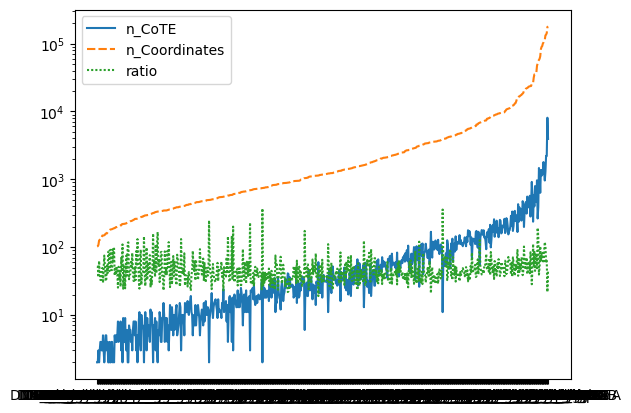

In [95]:
plt.yscale('log')
sns.lineplot(total.sort_values(by='n_Coordinates'), )

<Axes: >

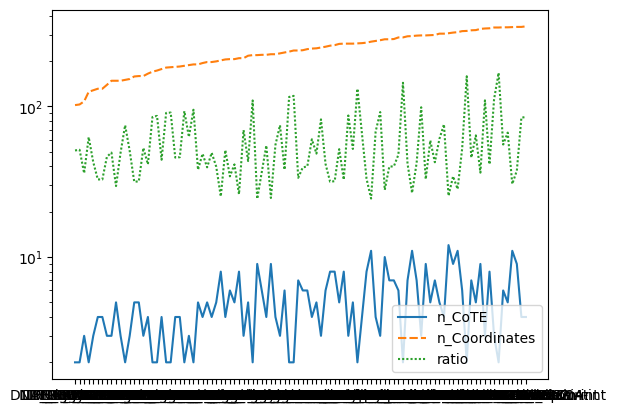

In [97]:
plt.yscale('log')
sns.lineplot(total.sort_values(by='n_Coordinates')[:100], )

<Axes: >

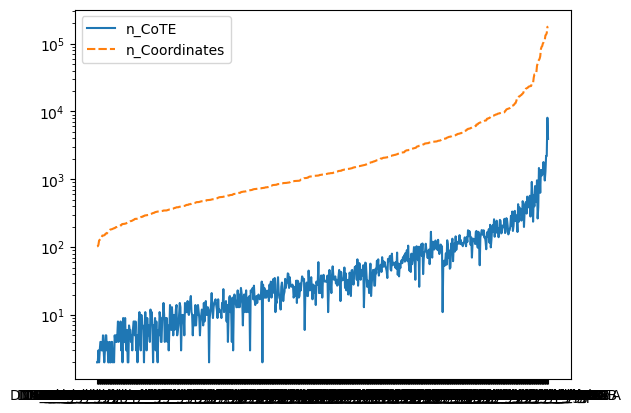

In [91]:
plt.yscale('log')
sns.lineplot(total.sort_values(by='n_Coordinates'), )

<Axes: >

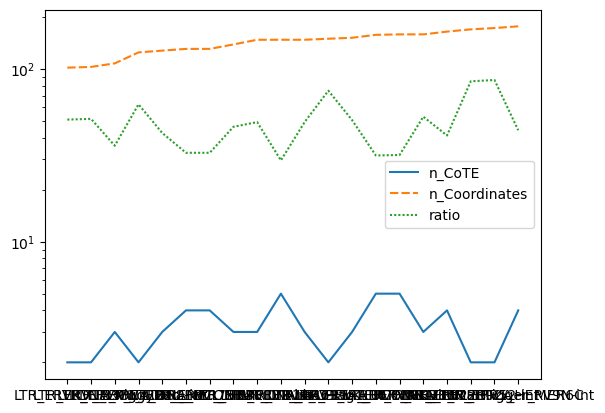

In [99]:
plt.yscale('log')
sns.lineplot(total.sort_values(by='n_Coordinates')[:20], )

<Axes: >

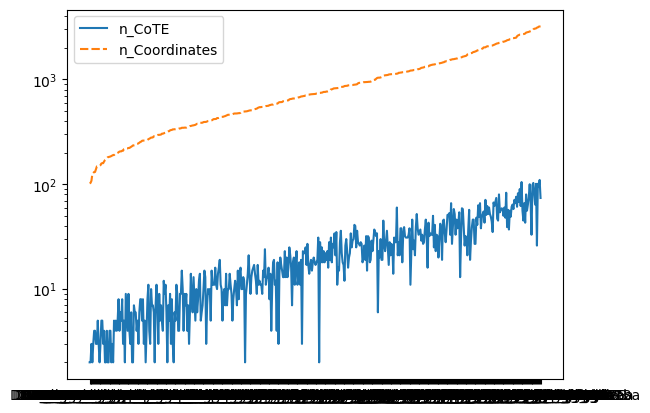

In [93]:
plt.yscale('log')
sns.lineplot(total.sort_values(by='n_Coordinates')[:500], )

([], [])

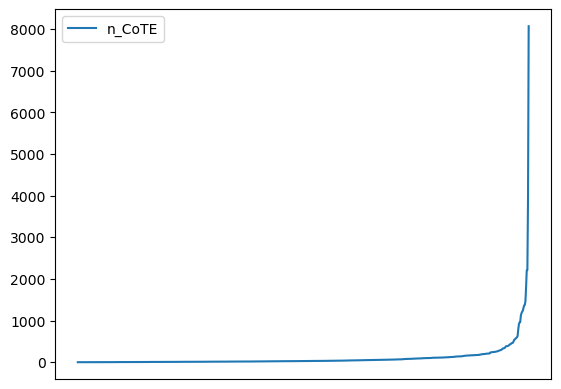

In [33]:
sns.lineplot(n_elements.sort_values(by='n_CoTE'))
plt.xticks([])

In [70]:
n_elements

,n_CoTE
LTR_ERVL-MaLR_MLT1D-int,16
LTR_ERV1_LTR8A,53
DNA_TcMar-Tigger_Tigger10,19
LTR_ERVL_LTR91,8
DNA_hAT-Tag1_UCON107,3
...,...
LTR_ERVL_MLT2D,119
LINE_L1_L1M6B,11
LTR_ERV1_MER57-int,17
DNA_hAT-Charlie_Charlie7,79


<Axes: ylabel='Density'>

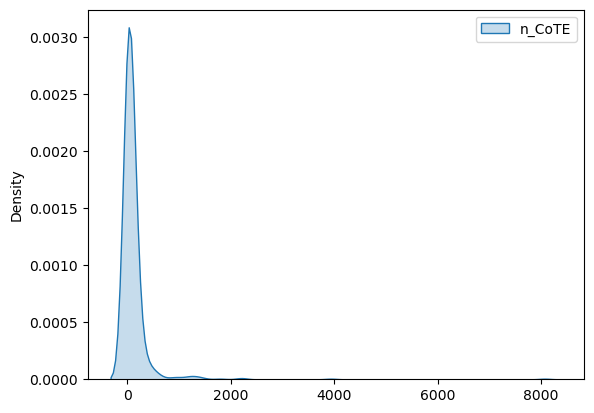

In [59]:
sns.kdeplot(n_elements.sort_values(by='n_CoTE'), fill=True)

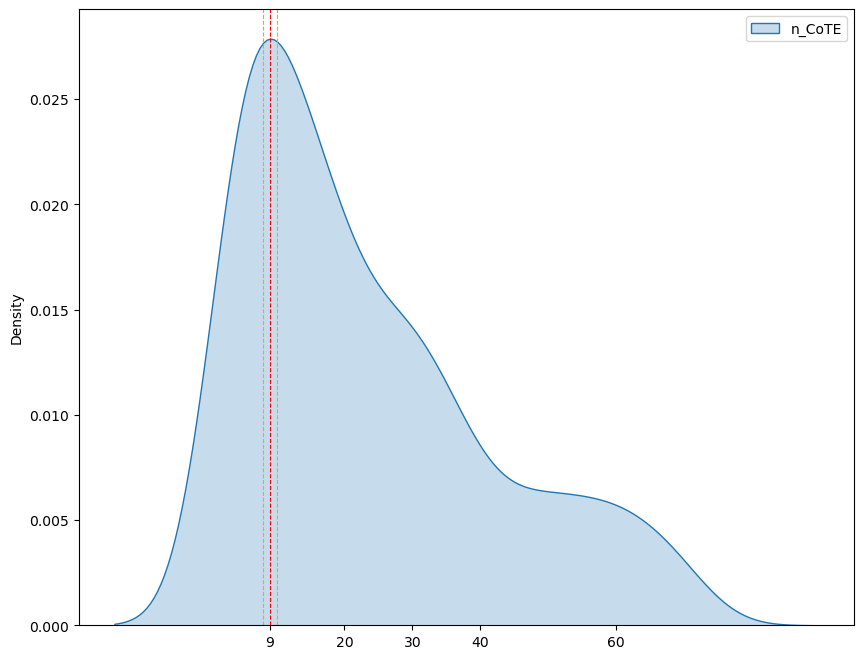

In [69]:
fig = plt.figure(figsize=(10, 8))
sns.kdeplot(n_elements.sort_values(by='n_CoTE')[:500], fill=True)
plt.axvline(x=9, color='r', linestyle='--', linewidth=0.8)
plt.axvline(x=10, color='orange', linestyle='--', linewidth=0.8)
plt.axvline(x=8, color='orange', linestyle='--', linewidth=0.8)
plt.xticks([ 9, 20, 30, 40, 60])
fig.savefig('/home/icb/mostafa.shahhosseini/data/lupien/results/n_cotes.png')
# plt.xticks([])

In [236]:
overlap_with_cotes(g, cos, 'Cosmic_genes', 'GENE_SYMBOL', '',  'genoName','genoStart','genoEnd', 'CHROMOSOME' ,	'GENOME_START' ,	'GENOME_STOP')

748it [06:57,  1.79it/s]


In [239]:
g['#cosmi_genes'] = g['Cosmic_genes'].apply(lambda x: len(x.split('[')))

In [241]:
ct = g[g['CoTE_Present']]
nct = g[~g['CoTE_Present']]

In [249]:
ct['#cosmi_genes'].sum()/g['#cosmi_genes'].sum()

0.13434283523783688

In [248]:
g['CoTE_Present'].sum()/g.shape[0]

0.1347469689585463

## TF

In [250]:
tf = pd.read_csv('/home/icb/mostafa.shahhosseini/data/lupien/V2_files/TF/DatabaseExtract_v_1.01.csv')

In [252]:
tf.columns

Index(['Unnamed: 0', 'Ensembl ID', 'HGNC symbol', 'DBD', 'Is TF?',
       'TF assessment', 'Binding mode', 'Motif status', 'Final Notes',
       'Final Comments', 'Interpro ID(s)', 'EntrezGene ID',
       'EntrezGene Description', 'PDB ID', 'TF tested by HT-SELEX?',
       'TF tested by PBM?', 'Conditional Binding Requirements ',
       'Original Comments', 'Vaquerizas 2009 classification',
       'CisBP considers it a TF?', 'TFCat classification', 'Is a GO TF?',
       'Initial assessment ', 'Curator 1', 'Curator 2',
       'TFclass considers it a TF? ', 'Go Evidence',
       'Pfam Domains (By ENSP ID)', 'Is C2H2 ZF(KRAB)?'],
      dtype='object')

## Chip-Seq

In [260]:
cs = pd.read_csv('/home/icb/mostafa.shahhosseini/data/lupien/V2_files/chip-seq/remap2022_nr_macs2_hg38_v1_0.bed', sep='\t', header=None)

In [261]:
cs = cs.iloc[:, :4]

In [265]:
cs.columns = ['genoName','genoStart','genoEnd', 'name']

In [266]:
cs

,genoName,genoStart,genoEnd,name
0,chr1,9829,10459,SMARCA4:HeLa
1,chr1,9880,10389,RELB:GM12878
2,chr1,9883,10270,MLLT1:GM12878
3,chr1,9884,10289,ZBTB10:HEK293
4,chr1,9889,10124,ZFP3:HEK293
...,...,...,...,...
68655736,chrY,56878597,56878810,AR:LNCaP-95
68655737,chrY,56878616,56878812,GATA2:LNCaP
68655738,chrY,56878659,56878902,"FOXA1:LNCaP,LNCaP-abl"
68655739,chrY,56883821,56883965,GATA2:LNCaP


## GTF

In [ ]:
columns = ['genoName', 'dataBase', 'type', 'genoStart', 'genoEnd', '5', '6', '7', '8']

gtf = pd.read_csv('/home/icb/mostafa.shahhosseini/data/lupien/V2_files/GTF/gencode.v46.annotation.gtf', sep='\t', skiprows=5, header=None, names=columns)

gtf['gene_name'] = gtf['8'].apply(lambda x: next((i.split(' ')[-1].replace("\"", '') for i in x.split(';') if 'gene_name' in i), None))

gtf = gtf.loc[:, ['genoName', 'type', 	'genoStart', 	'genoEnd', 'gene_name']]

In [24]:
gtf_dict = {}
for i in gtf['type'].unique():
    gtf_dict[i] = gtf[gtf['type']==i]

In [27]:
s = gtf_dict['exon']